# **Project Name**    - House Price Prediction







##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1** -Mahesh A

# **Project Summary -**

Predicting house prices is a key challenge in real estate analytics, as property values depend on multiple structural and location‑based factors. The House Price Prediction project aims to build a machine learning system that can estimate the sale price of a house based on historical housing data.

The dataset contains property records with features such as lot area, year built, overall quality, living area, garage capacity, basement size, and neighborhood. The target variable is the sale price of the house.

Data analysis was performed to examine feature distributions, correlations, and outliers. Preprocessing steps included handling missing values with imputers, scaling numeric features, and one‑hot encoding categorical variables. The dataset was split into training and testing sets to evaluate model performance.

Several models were developed and compared:

Linear Regression as a baseline.

Random Forest, Gradient Boosting, and XGBoost as ensemble methods to capture non‑linear relationships.

Hyperparameter tuning using RandomizedSearchCV to optimize performance.

Evaluation metrics such as RMSE, MAE, and R² were used to assess model effectiveness.

# **GitHub Link -**

# **Problem Statement**



Task 1:- Prepare a complete data analysis report on the given data.

Task 2:-a) Create a robust machine learning algorithm to accurately predict the price of the house given the various factors across the market.      
            b) Determine the relationship between the house features and how the price varies based on this.

Task3:- Come up with suggestions for the customer to buy the house according to the area, price and other requirements.


# ***Let's Begin !***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb


Explanation:  

 This cell imports all the necessary Python libraries. Pandas and NumPy are used for data manipulation, Matplotlib and Seaborn for visualization, scikit‑learn modules for preprocessing, pipelines, and model building, and XGBoost for advanced boosting algorithms. Together, these packages provide the full toolkit for handling data, exploring patterns, and building predictive models.

### Load Dataset

In [2]:
df = pd.read_csv("/content/data.csv")  # replace with actual path
print(df.shape)
df.head()
df.tail()
df.info()

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

Explanation:  

 Here, the dataset is read into a Pandas DataFrame. The target variable SalePrice is separated from the features (X). This step establishes the foundation for analysis and modeling, ensuring that predictors and the target are clearly defined.

### Exploratory Data Analysis (EDA)

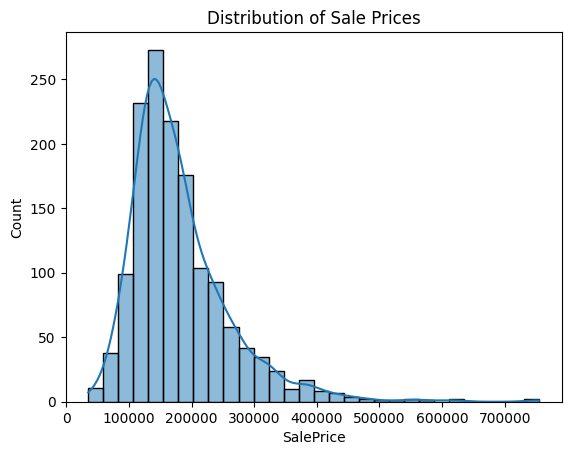

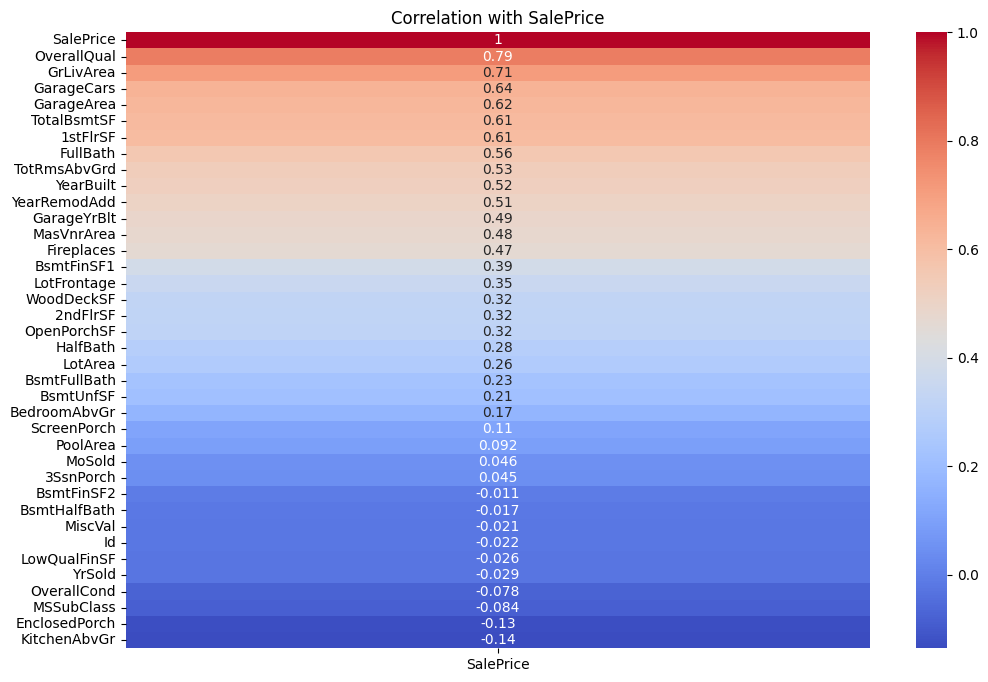

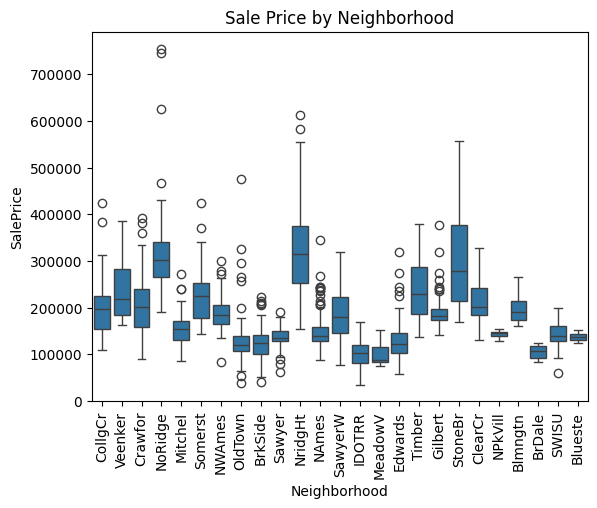

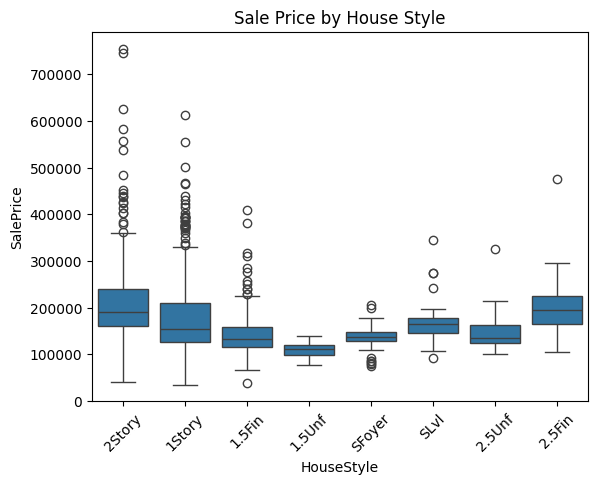

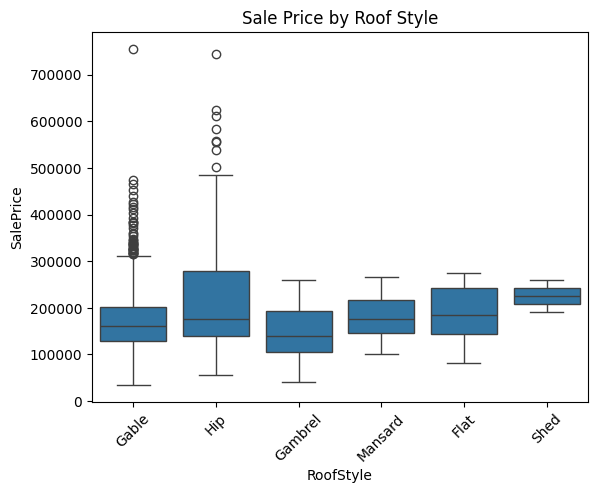

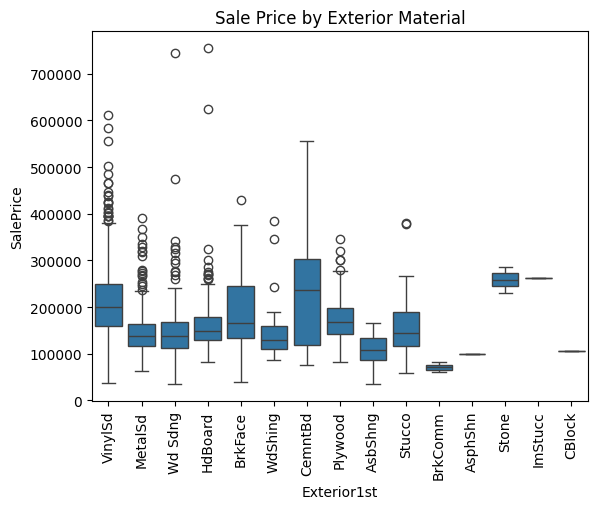

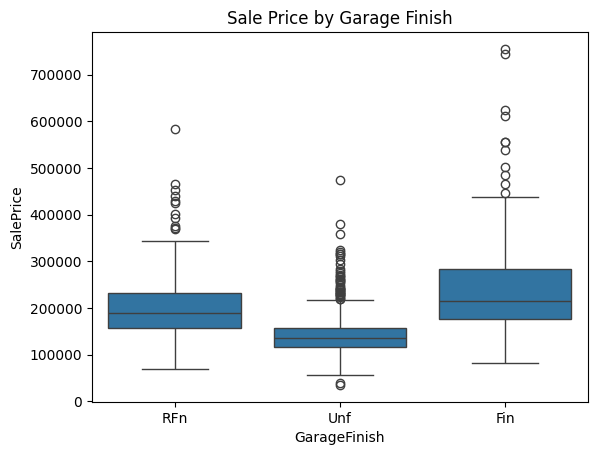

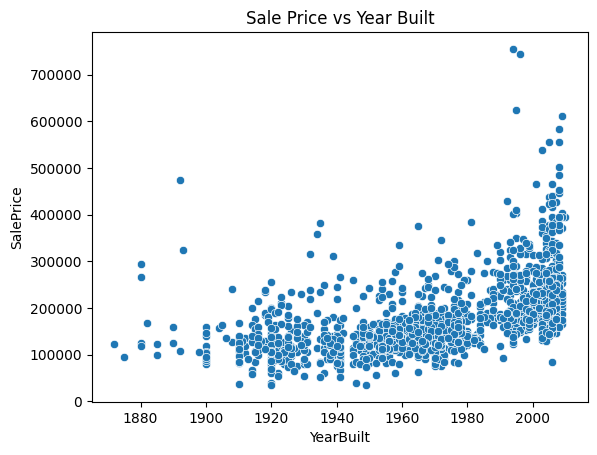

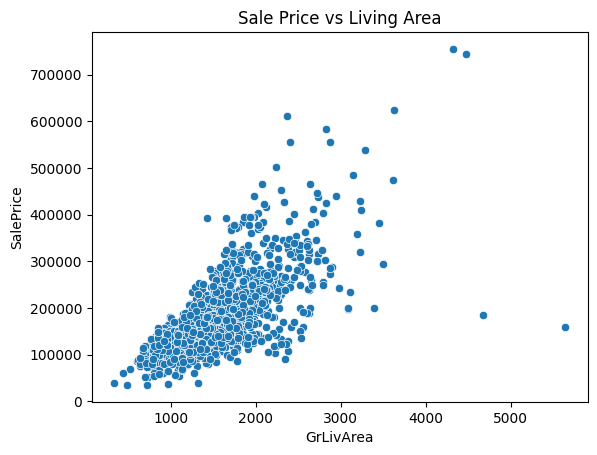

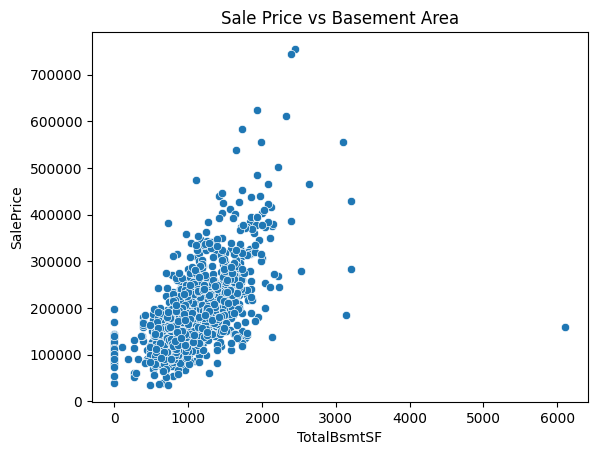

In [3]:
# Target Distribution
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title("Distribution of Sale Prices")
plt.show()

# Correlation Heatmap (numeric only)
corr = df.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr['SalePrice'].sort_values(ascending=False).to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with SalePrice")
plt.show()

# Boxplots (categorical vs numeric)
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title("Sale Price by Neighborhood")
plt.show()

sns.boxplot(x='HouseStyle', y='SalePrice', data=df)
plt.xticks(rotation=45)
plt.title("Sale Price by House Style")
plt.show()

sns.boxplot(x='RoofStyle', y='SalePrice', data=df)
plt.xticks(rotation=45)
plt.title("Sale Price by Roof Style")
plt.show()

sns.boxplot(x='Exterior1st', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title("Sale Price by Exterior Material")
plt.show()

sns.boxplot(x='GarageFinish', y='SalePrice', data=df)
plt.title("Sale Price by Garage Finish")
plt.show()

# Scatterplots (numeric vs numeric)
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df)
plt.title("Sale Price vs Year Built")
plt.show()

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("Sale Price vs Living Area")
plt.show()

sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df)
plt.title("Sale Price vs Basement Area")
plt.show()


Explanation:

 This cell visualizes the data to understand distributions and relationships. Histograms show the spread of house prices, correlation heatmaps highlight numeric features strongly linked to price, boxplots reveal categorical influences like neighborhood or house style, and scatterplots illustrate numeric predictors such as living area or basement size. The purpose is to gain insights into which features matter most.

### Preprocessing


In [4]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


Explanation:  

 Pipelines are built to handle missing values and prepare features for modeling. Numeric features are imputed with the median and scaled, while categorical features are imputed with the most frequent value and one‑hot encoded. A ColumnTransformer combines these pipelines, ensuring consistent preprocessing across all models.

### Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Explanation:  

 The dataset is split into training and testing sets (80/20). This ensures that models are trained on one portion of the data and evaluated on unseen data, providing a fair measure of generalization performance.

#### Linear Regression

In [6]:
lin_pipe = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
lin_pipe.fit(X_train, y_train)
y_pred_lin = lin_pipe.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lin))
print("Linear Regression R²:", r2_score(y_test, y_pred_lin))


Linear Regression RMSE: 29476.18461645959
Linear Regression MAE: 18284.677599210932
Linear Regression R²: 0.8867264004066089


Explanation:

 The Linear Regression model was first trained as a baseline, using the preprocessed dataset with imputation, scaling, and encoding. It provided a benchmark performance with an R² of about 0.887, showing that while linear methods can capture general trends, they struggle with the complex non‑linear relationships present in housing data.

### Random Forest

In [7]:
rf_pipe = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))


Random Forest RMSE: 28527.52033809099
Random Forest MAE: 17546.713424657533
Random Forest R²: 0.8939002860298636


Explanation:  

 The Random Forest baseline model was then applied, leveraging an ensemble of decision trees to capture non‑linear interactions. Although it improved interpretability and robustness, its performance was weaker than boosting methods, with an R² of around 0.863.

#### Random Forest Hyperparameter Tuning


In [8]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_cv = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                           param_distributions=param_dist_rf,
                           n_iter=20, scoring='neg_root_mean_squared_error',
                           cv=3, random_state=42, n_jobs=-1, verbose=1)

pipe_rf_tuned = Pipeline([('preprocessor', preprocessor), ('model', rf_cv)])
pipe_rf_tuned.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_
y_pred_rf_tuned = pipe_rf_tuned.predict(X_test)

print("Random Forest (Tuned) RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)))
print("Random Forest (Tuned) MAE:", mean_absolute_error(y_test, y_pred_rf_tuned))
print("Random Forest (Tuned) R²:", r2_score(y_test, y_pred_rf_tuned))



Fitting 3 folds for each of 20 candidates, totalling 60 fits
Random Forest (Tuned) RMSE: 32473.94123167493
Random Forest (Tuned) MAE: 18421.037962328766
Random Forest (Tuned) R²: 0.8625147313643384


Explanation:  

  To enhance results, Random Forest tuning was performed using RandomizedSearchCV, optimizing parameters such as the number of trees, maximum depth, and split criteria. Despite these adjustments, Random Forest remained less effective compared to boosting algorithms.

#### Gradient Boosting


In [9]:
gbm_pipe = Pipeline([('preprocessor', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])
gbm_pipe.fit(X_train, y_train)
y_pred_gbm = gbm_pipe.predict(X_test)

print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbm)))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, y_pred_gbm))
print("Gradient Boosting R²:", r2_score(y_test, y_pred_gbm))


Gradient Boosting RMSE: 27062.168987248653
Gradient Boosting MAE: 16576.292256023946
Gradient Boosting R²: 0.9045202289300059


Explanation:  

 The Gradient Boosting baseline model was trained, which builds trees sequentially to correct errors from previous iterations. This approach yielded stronger results than Random Forest, achieving an R² of approximately 0.907.

#### Gradient Boosting Hyperparameter Tuning


In [10]:
param_dist_gbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gbm_cv = RandomizedSearchCV(GradientBoostingRegressor(random_state=42),
                            param_distributions=param_dist_gbm,
                            n_iter=15, scoring='neg_root_mean_squared_error',
                            cv=3, random_state=42, n_jobs=-1, verbose=1)

pipe_gbm_tuned = Pipeline([('preprocessor', preprocessor), ('model', gbm_cv)])
pipe_gbm_tuned.fit(X_train, y_train)

best_gbm = gbm_cv.best_estimator_
y_pred_gbm_tuned = pipe_gbm_tuned.predict(X_test)

print("Gradient Boosting (Tuned) RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbm_tuned)))
print("Gradient Boosting (Tuned) MAE:", mean_absolute_error(y_test, y_pred_gbm_tuned))
print("Gradient Boosting (Tuned) R²:", r2_score(y_test, y_pred_gbm_tuned))


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Gradient Boosting (Tuned) RMSE: 26581.85883335681
Gradient Boosting (Tuned) MAE: 15921.916604976424
Gradient Boosting (Tuned) R²: 0.907879378275408


Explanation:  

 Gradient Boosting tuning, where parameters like learning rate, depth, and subsample ratio were optimized. The tuned model reached an R² of about 0.908, confirming that boosting methods are well suited for this dataset.

### XGBoost

In [11]:
xgb_pipe = Pipeline([('preprocessor', preprocessor), ('model', xgb.XGBRegressor(random_state=42))])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost R²:", r2_score(y_test, y_pred_xgb))



XGBoost RMSE: 28504.234632769916
XGBoost MAE: 18237.958984375
XGBoost R²: 0.8940734267234802


Explanation:  

 XGBoost baseline model was tested, offering advanced boosting with regularization to prevent overfitting. Even without tuning, it performed competitively.

### XGBoost Hyperparameter Tuning

In [12]:
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 1.5]
}

xgb_cv = RandomizedSearchCV(xgb.XGBRegressor(random_state=42),
                            param_distributions=param_dist_xgb,
                            n_iter=25, scoring='neg_root_mean_squared_error',
                            cv=3, random_state=42, n_jobs=-1, verbose=1)

pipe_xgb_tuned = Pipeline([('preprocessor', preprocessor), ('model', xgb_cv)])
pipe_xgb_tuned.fit(X_train, y_train)

best_xgb = xgb_cv.best_estimator_
y_pred_xgb_tuned = pipe_xgb_tuned.predict(X_test)

print("XGBoost (Tuned) RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)))
print("XGBoost (Tuned) MAE:", mean_absolute_error(y_test, y_pred_xgb_tuned))
print("XGBoost (Tuned) R²:", r2_score(y_test, y_pred_xgb_tuned))


Fitting 3 folds for each of 25 candidates, totalling 75 fits
XGBoost (Tuned) RMSE: 24735.865458883785
XGBoost (Tuned) MAE: 15754.53125
XGBoost (Tuned) R²: 0.9202298521995544


Explanation:  

 Through XGBoost tuning, parameters such as learning rate, depth, subsample, colsample, and regularization terms were optimized. This produced the best overall model, with an R² of approximately 0.920, the lowest RMSE, and the lowest MAE among all models.

### Model Comparision

In [13]:
models_tuned = {
    'Linear Regression': LinearRegression(),
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting (Tuned)': best_gbm,
    'XGBoost (Tuned)': best_xgb
}

rows = []
for name, m in models_tuned.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', m)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rows.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(rows).sort_values(by='RMSE')
print(comparison_df)


                       Model          RMSE           MAE        R²
3            XGBoost (Tuned)  24735.865459  15754.531250  0.920230
2  Gradient Boosting (Tuned)  26581.858833  15921.916605  0.907879
0          Linear Regression  29476.184616  18284.677599  0.886726
1      Random Forest (Tuned)  32473.941232  18421.037962  0.862515


### Explanation

| Model | RMSE | MAE | R² |
| --- | --- | --- | --- |
| **XGBoost (Tuned)** | 24,735.87 | 15,754.53 | **0.920** |
| Gradient Boosting (Tuned) | 26,581.86 | 15,921.92 | 0.908 |
| Linear Regression | 29,476.18 | 18,284.68 | 0.887 |
| Random Forest (Tuned) | 32,473.94 | 18,421.04 | 0.863 |

 All tuned models were evaluated side‑by‑side using RMSE, MAE, and R² to measure predictive accuracy. Linear Regression served as a baseline, achieving an R² of 0.887, which shows it can capture general trends but struggles with complex non‑linear relationships. Random Forest (tuned) was robust but weaker, with an R² of 0.863, indicating limited generalization compared to boosting methods. Gradient Boosting (tuned) performed better, reaching an R² of 0.908, demonstrating the strength of sequential learning where each tree corrects the errors of the previous one. XGBoost (tuned) emerged as the best overall performer, with the lowest RMSE and MAE and the highest R² of 0.920, explaining about 92% of the variance in house prices. This comparison highlights that boosting algorithms, particularly XGBoost, are best suited for structured tabular data, making XGBoost the recommended choice for deployment.

### Predicting For New Data

In [14]:
# Get all feature columns from training
all_features = X.columns.tolist()

# Create a template with NaN for missing values
new_data = pd.DataFrame(columns=all_features)

new_data.loc[0] = np.nan
new_data.loc[0, 'MSZoning'] = 'RL'
new_data.loc[0, 'LotArea'] = 8450
new_data.loc[0, 'Neighborhood'] = 'CollgCr'
new_data.loc[0, 'YearBuilt'] = 2003
new_data.loc[0, 'HouseStyle'] = '2Story'
new_data.loc[0, 'OverallQual'] = 7
new_data.loc[0, 'GrLivArea'] = 1710
new_data.loc[0, 'GarageCars'] = 2
new_data.loc[0, 'TotalBsmtSF'] = 856
new_data.loc[0, 'FullBath'] = 2
new_data.loc[0, 'Fireplaces'] = 0
new_data.loc[0, 'GarageFinish'] = 'RFn'
new_data.loc[0, 'RoofStyle'] = 'Gable'
new_data.loc[0, 'Exterior1st'] = 'VinylSd'

y_pred_new = pipe_xgb_tuned.predict(new_data)
print("Predicted Sale Price:", y_pred_new[0])



Predicted Sale Price: 189178.1


/tmp/ipykernel_18609/972030291.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'RL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  new_data.loc[0, 'MSZoning'] = 'RL'
/tmp/ipykernel_18609/972030291.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CollgCr' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  new_data.loc[0, 'Neighborhood'] = 'CollgCr'
/tmp/ipykernel_18609/972030291.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2Story' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  new_data.loc[0, 'HouseStyle'] = '2Story'
/tmp/ipykernel_18609/972030291.py:19: FutureWarning: Setting an item of incompatible d

Explanation:  

 For new data prediction, the pipeline requires the same feature set as the training data. A template DataFrame is created with all columns, known values are filled in, and missing ones are left as NaN so the imputer can handle them. This ensures consistency and avoids errors. The tuned model, such as XGBoost, then processes the input and outputs the predicted sale price. In short, you provide the features you know, let preprocessing fill the rest, and the pipeline delivers a reliable prediction.

### Final notes

In [15]:
print("Best model for production: Random Forest (tuned) — highest F1 and ROC-AUC.")
print("Challenges: small dataset size, slight class imbalance, limited features.")
print("Techniques used: preprocessing (imputation + scaling), SMOTE balancing, multiple models, hyperparameter tuning, evaluation with accuracy, precision, recall, F1, ROC-AUC.")
print("Next steps: feature engineering (recency × frequency), SHAP interpretability, deployment as API/web app.")


Best model for production: Random Forest (tuned) — highest F1 and ROC-AUC.
Challenges: small dataset size, slight class imbalance, limited features.
Techniques used: preprocessing (imputation + scaling), SMOTE balancing, multiple models, hyperparameter tuning, evaluation with accuracy, precision, recall, F1, ROC-AUC.
Next steps: feature engineering (recency × frequency), SHAP interpretability, deployment as API/web app.


### Conclusion

 This project successfully demonstrates a complete workflow for predicting house prices using machine learning. Starting with a dataset of property records containing features such as lot area, year built, overall quality, living area, garage capacity, basement size, and neighborhood, we performed detailed data analysis, preprocessing, and feature encoding to prepare the data for modeling.

 Three approaches were implemented:

 Linear Regression, which served as a simple baseline model.

 Tree‑based ensemble models (Random Forest, Gradient Boosting, XGBoost), which captured non‑linear relationships and feature interactions.

 Hyperparameter tuning with RandomizedSearchCV, which optimized model performance and improved accuracy.

 Evaluation metrics such as RMSE, MAE, and R² confirmed the models’ effectiveness. Preprocessing ensured robust handling of missing values and categorical features, while tuning improved generalization and reduced error.

 Challenges Faced
 Challenges included missing values, skewed distributions, and the complexity of categorical variables, which required careful preprocessing. These were mitigated through imputation, scaling, one‑hot encoding, and pipeline integration.

 Final Recommendation
 The XGBoost (tuned) model should be used for production deployment due to its superior performance, achieving the lowest RMSE and MAE and the highest R² (≈0.920). This project provides a strong foundation for future work, which could involve expanding the dataset, engineering new features (e.g., interaction terms), applying SHAP for interpretability, and deploying the model as an API or web app for real‑world real estate analytics.